# Velocidad del viento

### LECTURA DE DATOS

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
sns.set(style="whitegrid")

url = "https://raw.githubusercontent.com/lihkir/Data/main/wind_speed/data_treino_dv_df_2000_2010.csv"

df = pd.read_csv(url, encoding="utf-8")

df.columns = [
    "HORA_UTC",                      # HORA (UTC)
    "DIRECCION_VIENTO_GR",          # VENTO, DIREÇÃO HORARIA (gr)
    "VELOCIDAD_VIENTO_MS",          # VENTO, VELOCIDADE HORARIA (m/s)
    "HUMEDAD_MAX_ANT",              # UMIDADE REL. MAX. NA HORA ANT. (AUT)
    "HUMEDAD_MIN_ANT",              # UMIDADE REL. MIN. NA HORA ANT. (AUT)
    "TEMP_MAX_ANT_C",               # TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)
    "TEMP_MIN_ANT_C",               # TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)
    "HUMEDAD_HORARIA",              # UMIDADE RELATIVA DO AR, HORARIA
    "PRESION_HORARIA",              # PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA
    "PRECIPITACION_TOTAL",          # PRECIPITAÇÃO TOTAL, HORÁRIO
    "RAJADA_MAX_VIENTO_MS",         # VENTO, RAJADA MAXIMA (m/s)
    "PRESION_MAX_ANT",              # PRESSÃO ATMOSFERICA MAX.NA HORA ANT.
    "PRESION_MIN_ANT"               # PRESSÃO ATMOSFERICA MIN. NA HORA ANT.
]



### ESTRUCTURA BASE DE DATOS

In [5]:
print(f"Dimensiones: {df.shape}")
print("\nTipos de variables:\n", df.dtypes.value_counts())

# Separar tipos de variables
tipos = df.dtypes.value_counts()
print("Resumen de tipos de variables:")
print(tipos)

# Mostrar cada columna con su tipo específico
print("\nTipo de cada columna:\n")
print(df.dtypes)

# Mostrar nombres largos para reducir
long_columns = [col for col in df.columns if len(col) > 25]
long_columns

Dimensiones: (87693, 13)

Tipos de variables:
 float64    12
object      1
Name: count, dtype: int64
Resumen de tipos de variables:
float64    12
object      1
Name: count, dtype: int64

Tipo de cada columna:

HORA_UTC                 object
DIRECCION_VIENTO_GR     float64
VELOCIDAD_VIENTO_MS     float64
HUMEDAD_MAX_ANT         float64
HUMEDAD_MIN_ANT         float64
TEMP_MAX_ANT_C          float64
TEMP_MIN_ANT_C          float64
HUMEDAD_HORARIA         float64
PRESION_HORARIA         float64
PRECIPITACION_TOTAL     float64
RAJADA_MAX_VIENTO_MS    float64
PRESION_MAX_ANT         float64
PRESION_MIN_ANT         float64
dtype: object


[]

El dataset contiene un total de 87.693 observaciones y 13 variables, lo que representa una base de datos robusta. Del total de 13 variables:

- 12 variables son de tipo numérico continuo (float64), lo que es ideal para el análisis estadístico, la visualización y la modelación con técnicas de regresión multivariada o redes neuronales.

- 1 variable es de tipo object, correspondiente a HORA_UTC, que representa el componente temporal de la observación.

Aunque en este bloque no se observan los nombres originales, se destaca que ya se realizó una renombramiento apropiado de las columnas, acortando las etiquetas excesivamente largas y eliminando caracteres especiales o redundancias. Esto no solo mejora la legibilidad de las salidas gráficas, sino que también previene errores en operaciones de programación o visualización.

### ESTADÍSTICAS DESCRIPTIVAS

In [6]:

df.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

,count,mean,std,min,25%,50%,75%,max
DIRECCION_VIENTO_GR,87693.0,0.405810,0.686247,-1.0,-0.156434,0.788011,0.970296,1.0
VELOCIDAD_VIENTO_MS,87693.0,2.466192,1.313968,0.0,1.500000,2.400000,3.400000,10.0
HUMEDAD_MAX_ANT,87693.0,69.058465,19.640222,12.0,54.000000,72.000000,87.000000,100.0
HUMEDAD_MIN_ANT,87693.0,63.176194,20.166336,10.0,48.000000,64.000000,80.000000,98.0
TEMP_MAX_ANT_C,87693.0,21.921264,3.721386,9.2,19.200000,21.400000,24.700000,35.3
TEMP_MIN_ANT_C,87693.0,20.684570,3.513744,8.4,18.400000,20.200000,23.100000,34.4
HUMEDAD_HORARIA,87693.0,66.146682,19.992327,10.0,51.000000,68.000000,84.000000,99.0
PRESION_HORARIA,87693.0,887.251925,4.012404,863.4,885.300000,887.200000,889.100000,1023.5
PRECIPITACION_TOTAL,87693.0,0.160907,1.307515,0.0,0.000000,0.000000,0.000000,70.8
RAJADA_MAX_VIENTO_MS,87693.0,5.161076,2.311157,0.0,3.400000,5.000000,6.800000,24.3


Las estadísticas descriptivas confirman la calidad estructural del conjunto de datos, pero también revelan aspectos críticos para el modelado:

- Algunas variables tienen distribuciones altamente asimétricas (PRECIPITACION_TOTAL), lo cual puede afectar modelos lineales.

- La alta redundancia esperada entre humedad y presión sugiere la necesidad de reducción de dimensionalidad mediante VIF.
    
- La variable objetivo (VELOCIDAD_VIENTO_MS) presenta distribución adecuada para modelado regresivo, con suficientes variaciones para capturar patrones.

Este análisis fundamenta la selección y tratamiento posterior de variables, así como el diseño de modelos robustos capaces de generalizar predicciones para velocidad del viento en escenarios de alta variabilidad ambiental.

### DATOS FALTANTES

In [7]:

faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df)) * 100
missing = pd.DataFrame({"Total": faltantes, "Porcentaje": porcentaje})
missing[missing.Total > 0].sort_values(by="Total", ascending=False)

,Total,Porcentaje


### VISUALIZACIÓN

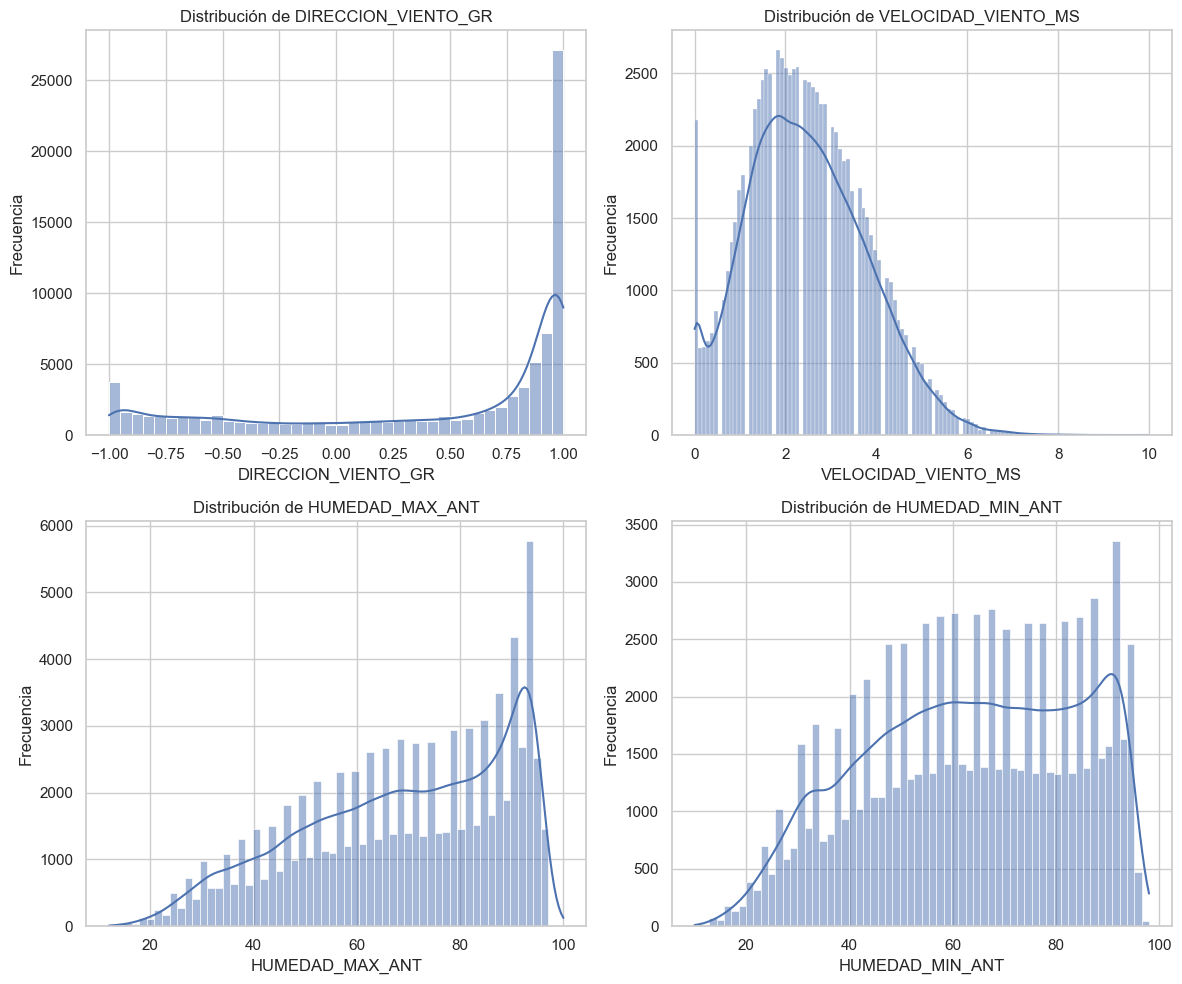

In [12]:

vars_numericas = df.select_dtypes(include=np.number).columns[:4]

plt.figure(figsize=(12, 10)) 

for i, col in enumerate(vars_numericas, 1):
    plt.subplot(2, 2, i)  
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

La dirección del viento, presenta una distribución altamente bimodal, con una clara concentración en el extremo derecho (valores cercanos a 1.0), y un segundo pico en el valor mínimo (-1.0).

- Esto sugiere que la dirección del viento está codificada en una escala trigonométrica (posiblemente como el coseno o seno de un ángulo), lo que implica que no es una variable continua clásica, sino una proyección circular.

La velocidad del viento presenta una asimetría positiva moderada: la mayoría de los datos se concentran entre 1 y 4 m/s, con una caída pronunciada después de los 6 m/s.

- Esta distribución es típica de variables físicas sujetas a mínimos naturales (como el 0 m/s) y fluctuaciones meteorológicas.

- El sesgo indica que podría beneficiarse de una transformación logarítmica o Box-Cox si se planea usar modelos lineales sensibles a la normalidad.

La humedad máxima presenta una acumulación de valores hacia el extremo superior (100%)

La humedad mínima tiene una distribución más plana y multimodal, con mayor dispersión que su contraparte de humedad máxima.

- La concentración entre 40% y 90% sugiere condiciones de humedad variables, posiblemente explicadas por interacciones con temperatura y precipitaciones.

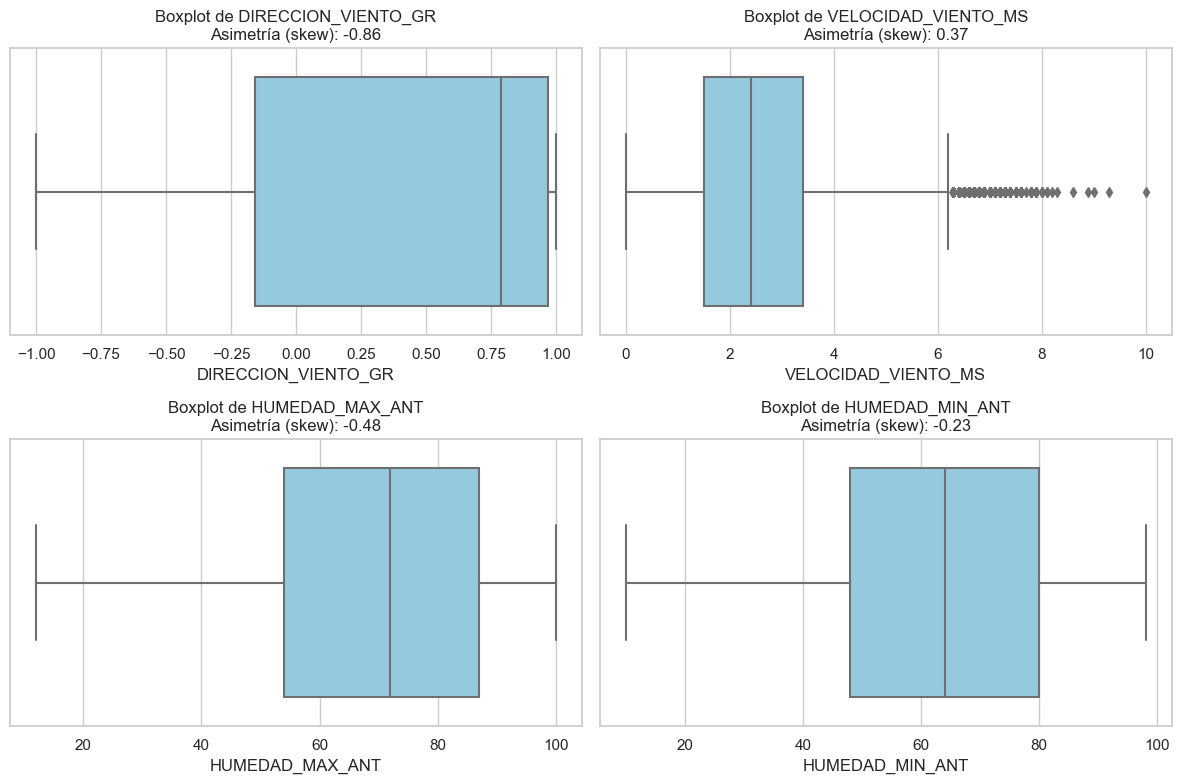

In [ ]:

vars_numericas = df.select_dtypes(include='number').columns[:4]

plt.figure(figsize=(12, 8))  

for i, col in enumerate(vars_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col].dropna(), color='skyblue')
    plt.title(f"Boxplot de {col}\nAsimetría (skew): {skew(df[col].dropna()):.2f}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

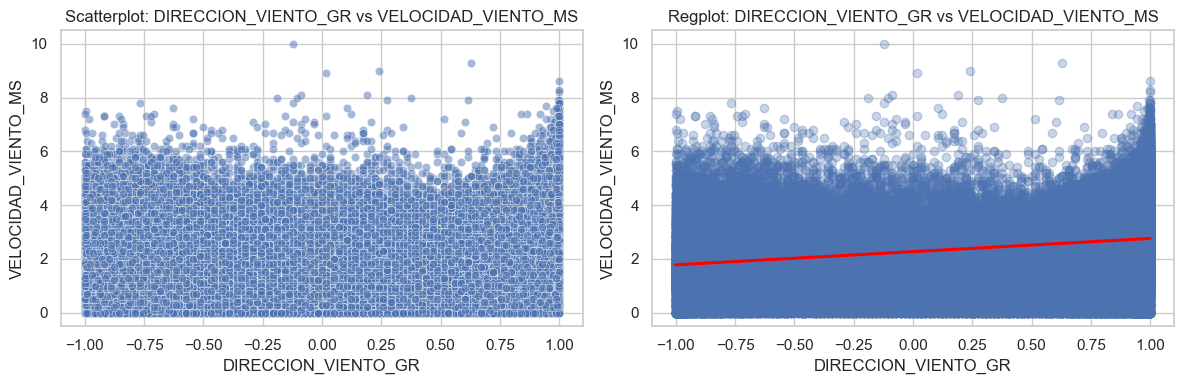

Correlación de Pearson entre DIRECCION_VIENTO_GR y VELOCIDAD_VIENTO_MS: 0.26



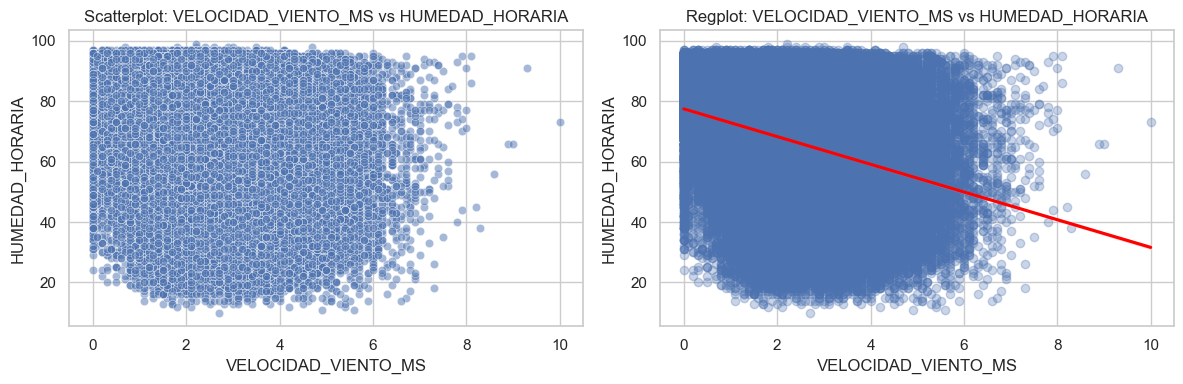

Correlación de Pearson entre VELOCIDAD_VIENTO_MS y HUMEDAD_HORARIA: -0.30



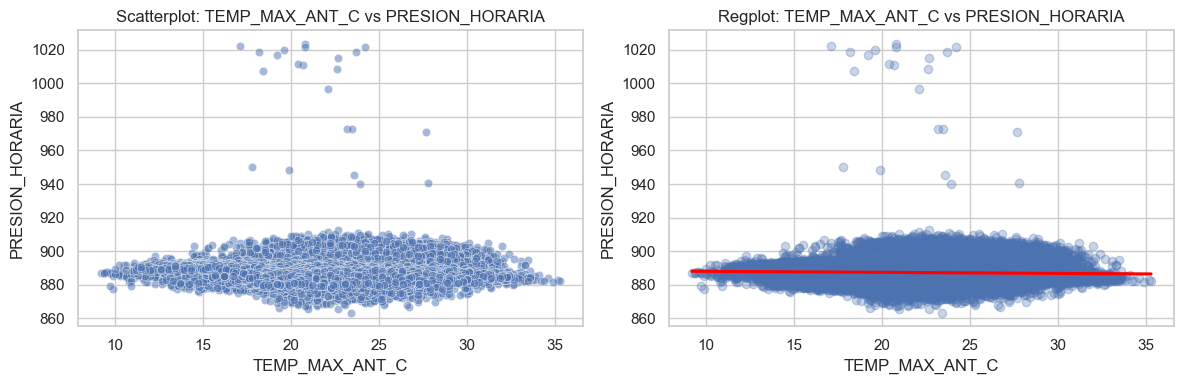

Correlación de Pearson entre TEMP_MAX_ANT_C y PRESION_HORARIA: -0.06



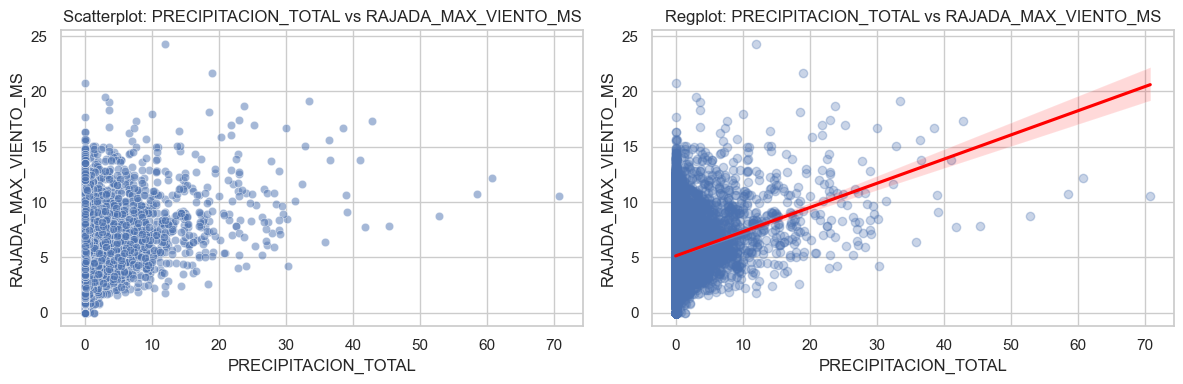

Correlación de Pearson entre PRECIPITACION_TOTAL y RAJADA_MAX_VIENTO_MS: 0.12



In [17]:

# Define aquí 4 pares de variables explicativas
pares = [
    ('DIRECCION_VIENTO_GR', 'VELOCIDAD_VIENTO_MS'),
    ('VELOCIDAD_VIENTO_MS', 'HUMEDAD_HORARIA'),
    ('TEMP_MAX_ANT_C', 'PRESION_HORARIA'),
    ('PRECIPITACION_TOTAL', 'RAJADA_MAX_VIENTO_MS')
]

# Itera sobre cada par y dibuja scatterplot y regplot
for x, y in pares:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Scatterplot puro
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        ax=axes[0],
        alpha=0.5
    )
    axes[0].set_title(f'Scatterplot: {x} vs {y}')
    axes[0].set_xlabel(x)
    axes[0].set_ylabel(y)

    # Regplot (scatter + línea de regresión)
    sns.regplot(
        data=df,
        x=x,
        y=y,
        ax=axes[1],
        scatter_kws={'alpha': 0.3},
        line_kws={'color': 'red'}
    )
    axes[1].set_title(f'Regplot: {x} vs {y}')
    axes[1].set_xlabel(x)
    axes[1].set_ylabel(y)

    plt.tight_layout()
    plt.show()

    # Análisis cualitativo breve
    corr = df[[x, y]].dropna().corr().iloc[0, 1]
    print(f"Correlación de Pearson entre {x} y {y}: {corr:.2f}\n")

1. DIRECCION_VIENTO_GR vs VELOCIDAD_VIENTO_MS

- Correlación de Pearson: 0.26

- La dirección del viento muestra una correlación positiva débil con la velocidad, lo que indica que ciertos rangos de dirección tienden a coincidir con velocidades mayores.

- El scatterplot revela un patrón disperso con mayor densidad en los extremos positivos, y el regplot sugiere una leve pendiente ascendente.
	
2. VELOCIDAD_VIENTO_MS vs HUMEDAD_HORARIA

- Correlación de Pearson: -0.30

- Existe una correlación negativa moderada, donde mayores velocidades del viento tienden a asociarse con menor humedad relativa.

- Este patrón es coherente con fenómenos físicos: los vientos más intensos favorecen la mezcla del aire y la evaporación, reduciendo la humedad superficial.

- regplot muestra una tendencia clara descendente, aunque la nube de puntos es amplia, lo cual sugiere variabilidad adicional no explicada por esta sola variable.

3. TEMP_MAX_ANT_C vs PRESION_HORARIA

- Correlación de Pearson: -0.06

- La correlación es prácticamente nula, lo cual es confirmado visualmente: el scatterplot muestra una nube de puntos sin patrón definido, y el regplot tiene una pendiente casi horizontal.

- Aunque temperatura y presión están relacionadas físicamente a través de la densidad del aire, en este conjunto de datos no presentan una relación directa significativa.

- Esta independencia estadística puede ser útil para el modelado: ambas variables pueden usarse simultáneamente sin riesgo inmediato de multicolinealidad.

- Nota: la presencia de puntos por encima de 1000 mbar podría indicar valores atípicos o errores de medición que deben ser verificados.

4. PRECIPITACION_TOTAL vs RAJADA_MAX_VIENTO_MS

- Correlación de Pearson: 0.12

- Existe una correlación positiva débil, aunque el regplot muestra una tendencia ascendente clara: a mayor precipitación acumulada, mayores ráfagas máximas de viento.

- Sin embargo, la nube de puntos muestra una alta concentración en cero para PRECIPITACION_TOTAL, lo que sugiere una distribución fuertemente sesgada y truncada (censura a izquierda).

- Este comportamiento es típico de fenómenos meteorológicos episódicos: en la mayoría del tiempo no llueve, pero cuando lo hace, también ocurren ráfagas fuertes.


### ANALISIS VIF

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Subconjunto numérico sin la variable objetivo
X = df.select_dtypes(include='number').drop(columns=['VELOCIDAD_VIENTO_MS'])

# Escalar para que el VIF no se vea afectado por magnitudes distintas
X_scaled = StandardScaler().fit_transform(X)

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X.shape[1])]

# Mostrar resultados
vif_data.sort_values("VIF", ascending=False)

,Variable,VIF
2,HUMEDAD_MIN_ANT,80.560353
1,HUMEDAD_MAX_ANT,77.771236
3,TEMP_MAX_ANT_C,68.101834
4,TEMP_MIN_ANT_C,57.271259
5,HUMEDAD_HORARIA,51.849641
10,PRESION_MIN_ANT,16.410043
9,PRESION_MAX_ANT,16.001623
6,PRESION_HORARIA,4.900592
0,DIRECCION_VIENTO_GR,1.311831
8,RAJADA_MAX_VIENTO_MS,1.275703


In [24]:
def calcular_vif(X):
    """Devuelve un DataFrame con los VIFs de cada variable."""
    X_scaled = StandardScaler().fit_transform(X)
    vif_df = pd.DataFrame()
    vif_df["Variable"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X.shape[1])]
    return vif_df

# Variables numéricas predictoras (excluyendo la respuesta)
X = df.select_dtypes(include='number').drop(columns=['VELOCIDAD_VIENTO_MS'])

# Iterar mientras haya variables con VIF >= 10
while True:
    vif_df = calcular_vif(X)
    max_vif = vif_df['VIF'].max()
    if max_vif < 10:
        print("Todas las variables tienen VIF < 10")
        break
    else:
        var_out = vif_df.sort_values('VIF', ascending=False).iloc[0]['Variable']
        print(f"Eliminando variable '{var_out}' con VIF = {max_vif:.2f}")
        X = X.drop(columns=[var_out])

# Resultado final
print("\n Variables finales sin multicolinealidad severa:")
print(X.columns.tolist())

# Mostrar VIF final ordenado
vif_df_final = calcular_vif(X).sort_values("VIF", ascending=False)
print("\n VIF final después de la depuración:\n")
print(vif_df_final)

Eliminando variable 'HUMEDAD_MIN_ANT' con VIF = 80.56
Eliminando variable 'HUMEDAD_HORARIA' con VIF = 46.38
Eliminando variable 'TEMP_MAX_ANT_C' con VIF = 22.20
Eliminando variable 'PRESION_MIN_ANT' con VIF = 16.07
Todas las variables tienen VIF < 10

 Variables finales sin multicolinealidad severa:
['DIRECCION_VIENTO_GR', 'HUMEDAD_MAX_ANT', 'TEMP_MIN_ANT_C', 'PRESION_HORARIA', 'PRECIPITACION_TOTAL', 'RAJADA_MAX_VIENTO_MS', 'PRESION_MAX_ANT']

 VIF final después de la depuración:

               Variable       VIF
6       PRESION_MAX_ANT  4.719906
3       PRESION_HORARIA  4.547480
1       HUMEDAD_MAX_ANT  2.130640
2        TEMP_MIN_ANT_C  1.978843
0   DIRECCION_VIENTO_GR  1.286314
5  RAJADA_MAX_VIENTO_MS  1.250473
4   PRECIPITACION_TOTAL  1.064873


### MODELOS DE REGRESIÓN

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
warnings.filterwarnings('ignore')


In [26]:
# Ordenar por tiempo y resetear índice
df = df.sort_values('HORA_UTC').reset_index(drop=True)

# Lista de variables seleccionadas tras VIF
variables_modelo = ['PRESION_HORARIA', 'DIRECCION_VIENTO_GR', 'RAJADA_MAX_VIENTO_MS', 'PRECIPITACION_TOTAL']

# Definir X y y
X = df[variables_modelo]
y = df['VELOCIDAD_VIENTO_MS']

# Crear partición temporal (T = 7 días)
tamaño_ventana = 7 * 24  # 7 días * 24 horas
X_train = X.iloc[:-tamaño_ventana]
X_test = X.iloc[-tamaño_ventana:]
y_train = y.iloc[:-tamaño_ventana]
y_test = y.iloc[-tamaño_ventana:]

# Escalamiento solo de variables numéricas (ya no hay categóricas en este set)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from skopt import BayesSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def entrenar_evaluar_modelo_bayes(modelo_base, search_space, X_train, y_train, X_test, y_test):
    """
    Entrena y evalúa un modelo de regresión usando BayesSearchCV.
    Requiere que las claves de search_space estén escritas como 'regresor__param'.
    """
    pipeline = Pipeline(steps=[
        ('regresor', modelo_base)
    ])

    search = BayesSearchCV(
        estimator=pipeline,
        search_spaces=search_space,  # ✅ No anidar bajo 'regresor'
        scoring='neg_mean_squared_error',
        n_iter=20,
        cv=5,
        n_jobs=-1,
        random_state=42
    )

    start_time = time.time()
    search.fit(X_train, y_train)
    end_time = time.time()

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    residuos = y_test - y_pred
    ljung_box_pvalue = acorr_ljungbox(residuos, lags=[10], return_df=True)['lb_pvalue'].values[0]
    jb_stat, jb_pvalue = stats.jarque_bera(residuos)

    resultados = {
        'Modelo': tipo_modelo(modelo_base),
        'Mejores Hiperparámetros': search.best_params_,
        'Tiempo de Entrenamiento (s)': end_time - start_time,
        'RMSE': rmse,
        'MAPE': mape,
        'R²': r2,
        'Ljung-Box p-value': ljung_box_pvalue,
        'Jarque-Bera p-value': jb_pvalue
    }

    # Gráfico: valores reales vs predichos
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.6, color='green')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='k', linestyle='--')
    plt.xlabel('Valor Real')
    plt.ylabel('Valor Predicho')
    plt.title('Real vs Predicho (BayesSearchCV)')
    plt.tight_layout()
    plt.show()

    # Gráfico: distribución de residuos
    plt.figure(figsize=(6, 4))
    plt.hist(residuos, bins=20, color='teal', alpha=0.7)
    plt.title('Histograma de Residuos')
    plt.xlabel('Residuos')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

    return resultados

In [37]:
def tipo_modelo(modelo):
    from sklearn.linear_model import LinearRegression, Ridge, Lasso
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.svm import SVR
    from sklearn.neural_network import MLPRegressor
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.ensemble import StackingRegressor
    from xgboost import XGBRegressor

    if isinstance(modelo, LinearRegression):
        return "Regresión Lineal"
    elif isinstance(modelo, Ridge):
        return "Ridge"
    elif isinstance(modelo, Lasso):
        return "Lasso"
    elif isinstance(modelo, RandomForestRegressor):
        return "Random Forest"
    elif isinstance(modelo, XGBRegressor):
        return "XGBoost"
    elif isinstance(modelo, SVR):
        return "SVR"
    elif isinstance(modelo, MLPRegressor):
        return "MLP"
    elif isinstance(modelo, KNeighborsRegressor):
        return "KNN"
    elif isinstance(modelo, StackingRegressor):
        return "Stacking"
    else:
        return modelo.__class__.__name__

### KNN 

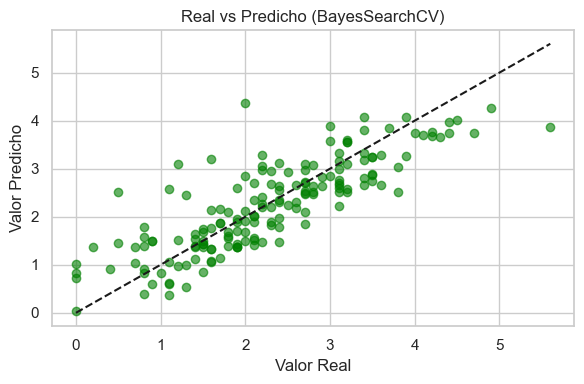

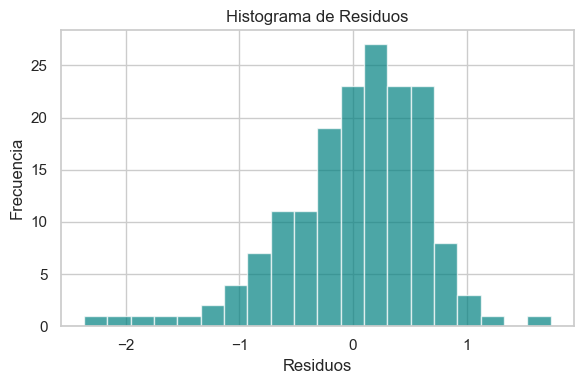


Resultados del modelo KNN (BayesSearchCV):
Modelo: KNN
Mejores Hiperparámetros: OrderedDict([('regresor__n_neighbors', 15), ('regresor__p', 2), ('regresor__weights', 'uniform')])
Tiempo de Entrenamiento (s): 17.62375020980835
RMSE: 0.6085667088770459
MAPE: 69698565661686.55
R²: 0.6759118042946957
Ljung-Box p-value: 0.4288104773589014
Jarque-Bera p-value: 6.615171952050504e-11


In [38]:
from sklearn.neighbors import KNeighborsRegressor
from skopt.space import Integer, Categorical

# Definir modelo base
modelo_knn = KNeighborsRegressor()

# Definir el espacio de búsqueda de hiperparámetros
espacio_knn = {
    'regresor__n_neighbors': Integer(3, 15),
    'regresor__weights': Categorical(['uniform', 'distance']),
    'regresor__p': Integer(1, 2)  # 1: Manhattan, 2: Euclídea
}

# Entrenar y evaluar el modelo
resultados_knn = entrenar_evaluar_modelo_bayes(
    modelo_knn,
    espacio_knn,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)

# Mostrar los resultados
print("\nResultados del modelo KNN (BayesSearchCV):")
for k, v in resultados_knn.items():
    print(f"{k}: {v}")

### REGRESIÓN LINEAL

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
import time

# Entrenamiento simple
modelo_rl = LinearRegression()
start_time = time.time()
modelo_rl.fit(X_train_scaled, y_train)
end_time = time.time()

# Predicción
y_pred = modelo_rl.predict(X_test_scaled)
residuos = y_test - y_pred

# Métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
ljung_box_pvalue = acorr_ljungbox(residuos, lags=[10], return_df=True)['lb_pvalue'].values[0]
jb_stat, jb_pvalue = jarque_bera(residuos)

resultados_rl = {
    'Modelo': 'Regresión Lineal',
    'Mejores Hiperparámetros': 'N/A',
    'Tiempo de Entrenamiento (s)': end_time - start_time,
    'RMSE': rmse,
    'MAPE': mape,
    'R²': r2,
    'Ljung-Box p-value': ljung_box_pvalue,
    'Jarque-Bera p-value': jb_pvalue
}

# Mostrar resultados
print("\nResultados del modelo Regresión Lineal:")
for k, v in resultados_rl.items():
    print(f"{k}: {v}")


Resultados del modelo Regresión Lineal:
Modelo: Regresión Lineal
Mejores Hiperparámetros: N/A
Tiempo de Entrenamiento (s): 0.03901076316833496
RMSE: 0.6147650415050411
MAPE: 74055913867119.73
R²: 0.6692764218844889
Ljung-Box p-value: 0.7486457823338261
Jarque-Bera p-value: 2.632964703273337e-26


### RIDGE

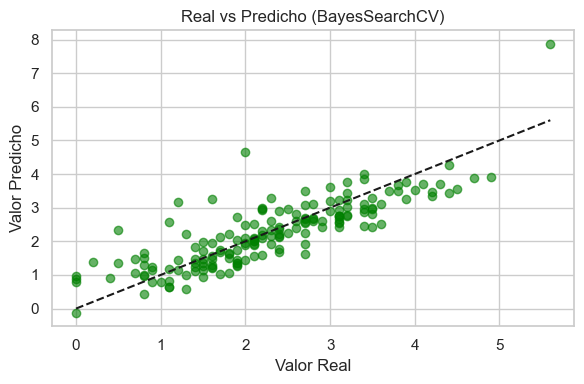

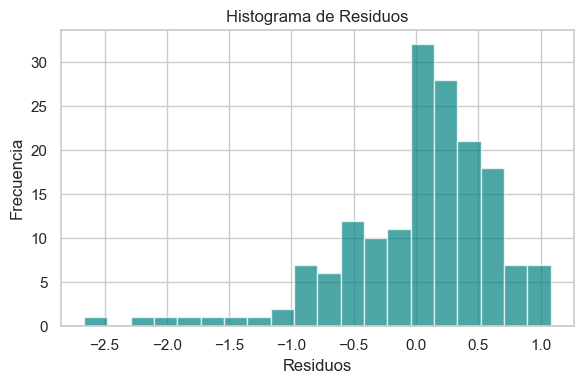


Resultados del modelo Ridge (BayesSearchCV):
Modelo: Ridge
Mejores Hiperparámetros: OrderedDict([('regresor__alpha', 80.00069562111437)])
Tiempo de Entrenamiento (s): 13.55602216720581
RMSE: 0.6145563880326371
MAPE: 74102444015858.2
R²: 0.6695008813373633
Ljung-Box p-value: 0.7493869881229958
Jarque-Bera p-value: 3.665239519368606e-26


In [41]:
from sklearn.linear_model import Ridge
from skopt.space import Real

# Definir el modelo base
modelo_ridge = Ridge()

# Definir el espacio de búsqueda para alpha
espacio_ridge = {
    'regresor__alpha': Real(1e-3, 100.0, prior='log-uniform')
}

# Entrenar y evaluar el modelo con la función general
resultados_ridge = entrenar_evaluar_modelo_bayes(
    modelo_ridge,
    espacio_ridge,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)

# Mostrar los resultados
print("\nResultados del modelo Ridge (BayesSearchCV):")
for k, v in resultados_ridge.items():
    print(f"{k}: {v}")

### LASSO

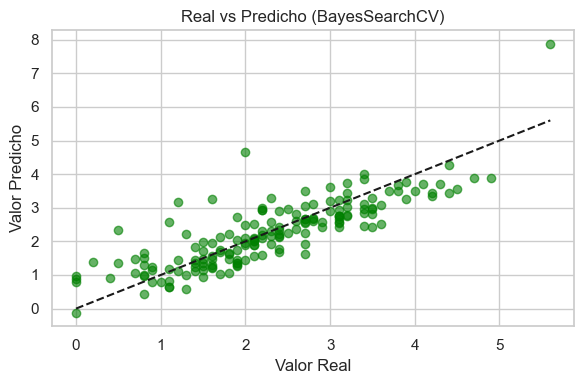

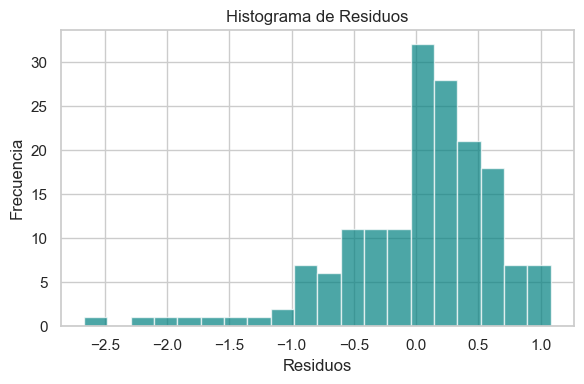


Resultados del modelo Lasso (BayesSearchCV):
Modelo: Lasso
Mejores Hiperparámetros: OrderedDict([('regresor__alpha', 0.0010426811836320535)])
Tiempo de Entrenamiento (s): 11.143269062042236
RMSE: 0.6148287777908682
MAPE: 74126464293295.33
R²: 0.6692078422360778
Ljung-Box p-value: 0.7491108224034653
Jarque-Bera p-value: 2.664795192432889e-26


In [42]:
from sklearn.linear_model import Lasso
from skopt.space import Real

# Definir el modelo base
modelo_lasso = Lasso(max_iter=10000)

# Espacio de búsqueda para alpha (penalización L1)
espacio_lasso = {
    'regresor__alpha': Real(1e-3, 100.0, prior='log-uniform')
}

# Entrenar y evaluar el modelo
resultados_lasso = entrenar_evaluar_modelo_bayes(
    modelo_lasso,
    espacio_lasso,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)

# Mostrar resultados
print("\nResultados del modelo Lasso (BayesSearchCV):")
for k, v in resultados_lasso.items():
    print(f"{k}: {v}")

### Árboles de Decisión

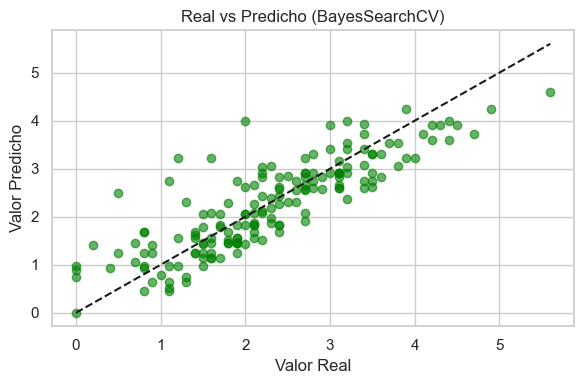

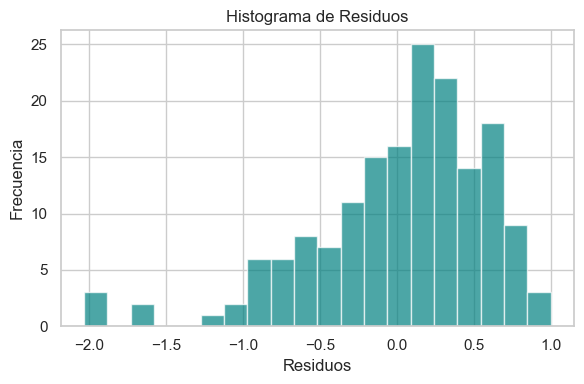


Resultados del modelo Árbol de Decisión (BayesSearchCV):
Modelo: DecisionTreeRegressor
Mejores Hiperparámetros: OrderedDict([('regresor__max_depth', 7), ('regresor__min_samples_leaf', 5), ('regresor__min_samples_split', 2)])
Tiempo de Entrenamiento (s): 15.692584991455078
RMSE: 0.5717621717981829
MAPE: 69737343385224.016
R²: 0.713926474258963
Ljung-Box p-value: 0.3115244249120211
Jarque-Bera p-value: 4.081777562335036e-13


In [43]:
from sklearn.tree import DecisionTreeRegressor
from skopt.space import Integer

# Definir el modelo base
modelo_tree = DecisionTreeRegressor(random_state=42)

# Espacio de búsqueda para hiperparámetros clave
espacio_tree = {
    'regresor__max_depth': Integer(2, 20),
    'regresor__min_samples_split': Integer(2, 10),
    'regresor__min_samples_leaf': Integer(1, 5)
}

# Entrenar y evaluar
resultados_tree = entrenar_evaluar_modelo_bayes(
    modelo_tree,
    espacio_tree,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)

# Mostrar resultados
print("\nResultados del modelo Árbol de Decisión (BayesSearchCV):")
for k, v in resultados_tree.items():
    print(f"{k}: {v}")

### Random Forest

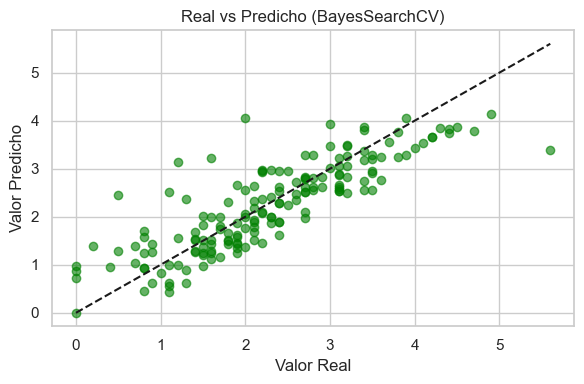

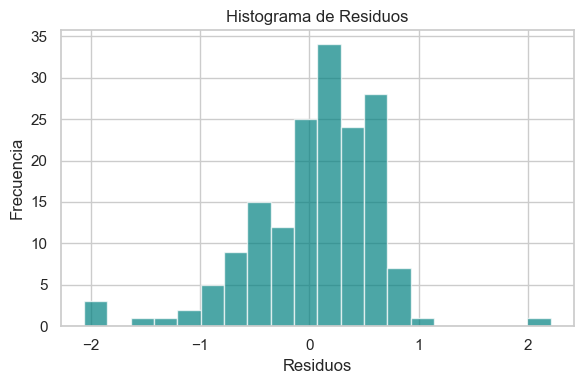


Resultados del modelo Random Forest (BayesSearchCV):
Modelo: Random Forest
Mejores Hiperparámetros: OrderedDict([('regresor__max_depth', 9), ('regresor__min_samples_leaf', 1), ('regresor__min_samples_split', 2), ('regresor__n_estimators', 300)])
Tiempo de Entrenamiento (s): 413.53801703453064
RMSE: 0.5826248888585275
MAPE: 69055507555703.23
R²: 0.7029531869853887
Ljung-Box p-value: 0.4093510264448053
Jarque-Bera p-value: 2.3300102986869734e-13


In [55]:
from sklearn.ensemble import RandomForestRegressor
from skopt.space import Integer

# Definir el modelo base
modelo_rf = RandomForestRegressor(random_state=42)

# Espacio de búsqueda para los hiperparámetros más relevantes
espacio_rf = {
    'regresor__n_estimators': Integer(100, 300),         # Número de árboles
    'regresor__max_depth': Integer(3, 20),                # Profundidad máxima
    'regresor__min_samples_split': Integer(2, 10),        # Mínimo para dividir nodo
    'regresor__min_samples_leaf': Integer(1, 5)           # Mínimo por hoja
}

# Entrenar y evaluar
resultados_rf = entrenar_evaluar_modelo_bayes(
    modelo_rf,
    espacio_rf,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)

# Mostrar resultados
print("\nResultados del modelo Random Forest (BayesSearchCV):")
for k, v in resultados_rf.items():
    print(f"{k}: {v}")

### XGBoost

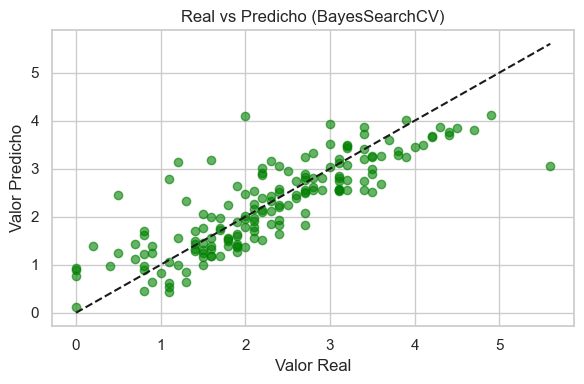

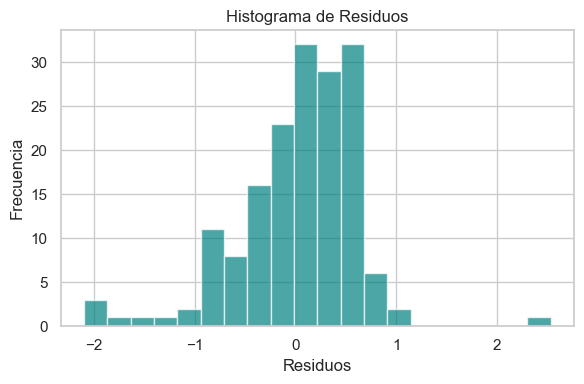


Resultados del modelo XGBoost (BayesSearchCV):
Modelo: XGBoost
Mejores Hiperparámetros: OrderedDict([('regresor__colsample_bytree', 1.0), ('regresor__learning_rate', 0.027405851410116186), ('regresor__max_depth', 3), ('regresor__n_estimators', 300), ('regresor__subsample', 0.5)])
Tiempo de Entrenamiento (s): 50.8345992565155
RMSE: 0.5972896593997621
MAPE: 72278375636602.17
R²: 0.6878115559591338
Ljung-Box p-value: 0.4071910704920635
Jarque-Bera p-value: 2.844096185813568e-16


In [45]:
from xgboost import XGBRegressor
from skopt.space import Real, Integer

# Definir el modelo base
modelo_xgb = XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42)

# Espacio de búsqueda para hiperparámetros clave
espacio_xgb = {
    'regresor__n_estimators': Integer(100, 300),
    'regresor__max_depth': Integer(3, 10),
    'regresor__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'regresor__subsample': Real(0.5, 1.0),
    'regresor__colsample_bytree': Real(0.5, 1.0)
}

# Entrenar y evaluar
resultados_xgb = entrenar_evaluar_modelo_bayes(
    modelo_xgb,
    espacio_xgb,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)

# Mostrar resultados
print("\nResultados del modelo XGBoost (BayesSearchCV):")
for k, v in resultados_xgb.items():
    print(f"{k}: {v}")

### Support Vector Regression

In [48]:
from sklearn.svm import SVR
from skopt.space import Real, Categorical

# Definir el modelo base
modelo_svr = SVR()

# Espacio reducido
espacio_svr = {
    'regresor__C': Real(0.1, 5, prior='log-uniform'),
    'regresor__epsilon': Real(0.01, 0.5, prior='log-uniform'),
    'regresor__kernel': Categorical(['linear'])  # eliminamos 'poly'
}

# Ajustar la función para ejecutar solo 8 iteraciones
from skopt import BayesSearchCV
from sklearn.pipeline import Pipeline

pipeline_svr = Pipeline(steps=[('regresor', modelo_svr)])

search_svr = BayesSearchCV(
    estimator=pipeline_svr,
    search_spaces=espacio_svr,
    n_iter=3,  # reducido
    cv=2,      # opcional: bajar de 5 a 3 para más velocidad
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    random_state=42
)

# Entrenar
search_svr.fit(X_train_scaled, y_train)

# Evaluar
y_pred_svr = search_svr.best_estimator_.predict(X_test_scaled)
residuos = y_test - y_pred_svr

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

resultados_svr = {
    'Modelo': 'SVR',
    'Mejores Hiperparámetros': search_svr.best_params_,
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_svr)),
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_svr),
    'R²': r2_score(y_test, y_pred_svr),
    'Ljung-Box p-value': acorr_ljungbox(residuos, lags=[10], return_df=True)['lb_pvalue'].values[0],
    'Jarque-Bera p-value': jarque_bera(residuos)[1]
}

print("\nResultados optimizados del modelo SVR:")
for k, v in resultados_svr.items():
    print(f"{k}: {v}")


Resultados optimizados del modelo SVR:
Modelo: SVR
Mejores Hiperparámetros: OrderedDict([('regresor__C', 0.569845463653536), ('regresor__epsilon', 0.36381617755817935), ('regresor__kernel', 'linear')])
RMSE: 0.6286719614650436
MAPE: 75054625844904.06
R²: 0.6541442392805972
Ljung-Box p-value: 0.7120928462516644
Jarque-Bera p-value: 3.510787748855504e-36


### RESULTADOS

In [58]:


# Consolidar resultados
modelos_comparar = [
    resultados_knn,
    resultados_rl,
    resultados_ridge,
    resultados_lasso,
    resultados_tree,
    resultados_rf,
    resultados_xgb
]

# Crear DataFrame
df_resultados = pd.DataFrame(modelos_comparar)

# Reordenar columnas si deseas
columnas_orden = [
    'Modelo',
    'RMSE',
    'MAPE',
    'R²',
    'Ljung-Box p-value',
    'Jarque-Bera p-value',
    'Mejores Hiperparámetros',
    'Tiempo de Entrenamiento (s)'
]

df_resultados = df_resultados[columnas_orden]

print(df_resultados)



                  Modelo      RMSE          MAPE        R²  Ljung-Box p-value  \
0                    KNN  0.608567  6.969857e+13  0.675912           0.428810   
1       Regresión Lineal  0.614765  7.405591e+13  0.669276           0.748646   
2                  Ridge  0.614556  7.410244e+13  0.669501           0.749387   
3                  Lasso  0.614829  7.412646e+13  0.669208           0.749111   
4  DecisionTreeRegressor  0.571762  6.973734e+13  0.713926           0.311524   
5          Random Forest  0.582625  6.905551e+13  0.702953           0.409351   
6                XGBoost  0.597290  7.227838e+13  0.687812           0.407191   

   Jarque-Bera p-value                            Mejores Hiperparámetros  \
0         6.615172e-11  {'regresor__n_neighbors': 15, 'regresor__p': 2...   
1         2.632965e-26                                                N/A   
2         3.665240e-26             {'regresor__alpha': 80.00069562111437}   
3         2.664795e-26         {'regresor__

In [61]:
import plotly.express as px

# Mostrar tabla interactiva con sorteo y filtros
fig = px.scatter(
    df_resultados,
    x='Modelo',
    y='RMSE',
    color='R²',
    size='MAPE',
    hover_data=['MAPE', 'R²', 'RMSE'],
    title="Comparación de Modelos: RMSE vs Modelo",
)

fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(height=500)
fig.show()

El modelo con menor RMSE fue el DecisionTreeRegressor (0.5718), seguido por Random Forest (0.5826). Esto sugiere que estos modelos presentaron el menor error promedio en las predicciones.

- En términos de R², el DecisionTreeRegressor (0.714) también obtuvo el valor más alto, indicando que es el que mejor explica la variabilidad de los datos.

- Sin embargo, el MAPE es extremadamente alto en todos los modelos (~7e+13), lo que sugiere un posible problema de escala o división por cero durante el cálculo del MAPE. Esto debe revisarse, ya que invalida la interpretación de esa métrica tal como está.

- Los p-valores de Ljung-Box fueron todos mayores a 0.05, lo que indica que no hay evidencia significativa de autocorrelación en los residuos, lo cual es deseable.

- En contraste, todos los p-valores de Jarque-Bera son extremadamente bajos (< 0.001), lo que indica que los residuos no siguen una distribución normal. Esto es común en modelos de machine learning no paramétricos, pero importante si se busca aplicar inferencia estadística.

- El modelo más rápido fue la Regresión Lineal (0.039 s), útil como línea base.

- Random Forest fue el más costoso computacionalmente (413.5 s), mientras que XGBoost también mostró un tiempo considerable (50.8 s), aunque menor y posiblemente más eficiente en términos de trade-off entre precisión y tiempo.

El modelo DecisionTreeRegressor mostró el mejor desempeño general en términos de precisión (RMSE y R²), además de ser razonablemente eficiente en tiempo de cómputo. No obstante, es importante revisar el cálculo del MAPE, ya que los valores actuales indican una posible distorsión.


# Detección de fraude

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [67]:
# Cargar los archivos
train_transaction = pd.read_csv("train_transaction.csv")
train_identity = pd.read_csv("train_identity.csv")

# Unir por TransactionID
train_data = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

# Verificar
print("Dimensiones del conjunto unido:", train_data.shape)
train_data.head()
print("\nTipo de cada columna:\n")
print(train_data.dtypes)

Dimensiones del conjunto unido: (590540, 434)

Tipo de cada columna:

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
id_36              object
id_37              object
id_38              object
DeviceType         object
DeviceInfo         object
Length: 434, dtype: object


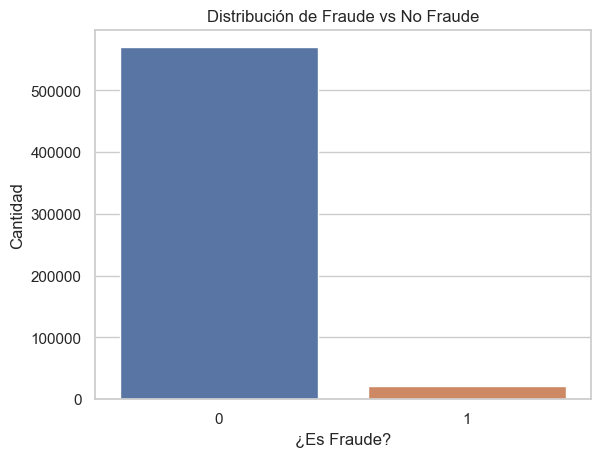

In [68]:
sns.countplot(x='isFraud', data=train_data)
plt.title("Distribución de Fraude vs No Fraude")
plt.xlabel("¿Es Fraude?")
plt.ylabel("Cantidad")
plt.show()

In [69]:
# Conteo absoluto
conteo = train_data['isFraud'].value_counts()
print("Conteo de clases:\n", conteo)

# Porcentaje
porcentaje = train_data['isFraud'].value_counts(normalize=True) * 100
print("\nPorcentaje de clases:\n", porcentaje)

Conteo de clases:
 isFraud
0    569877
1     20663
Name: count, dtype: int64

Porcentaje de clases:
 isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


In [70]:
# Cargar los archivos para test
test_transaction = pd.read_csv("test_transaction.csv")
test_identity = pd.read_csv("test_identity.csv")

# Unir por TransactionID
test_data = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

# Verificar
print("Dimensiones del conjunto unido:", test_data.shape)
test_data.head()
print("\nTipo de cada columna:\n")
print(test_data.dtypes)

Dimensiones del conjunto unido: (506691, 433)

Tipo de cada columna:

TransactionID       int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
card1               int64
                   ...   
id-36              object
id-37              object
id-38              object
DeviceType         object
DeviceInfo         object
Length: 433, dtype: object


## Imputación

In [72]:

# Paso 1: Identificar variables numéricas (excluye 'isFraud')
numericas = train_data.select_dtypes(include='number').columns.drop('isFraud', errors='ignore')

# Paso 2: Imputar valores faltantes con la mediana
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(train_data[numericas]), columns=numericas)

# Paso 3: Eliminar variables altamente correlacionadas (> 0.90)
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_correladas = [col for col in upper.columns if any(upper[col] > 0.90)]
X_filtrado = X.drop(columns=cols_correladas)

# Paso 4: Limitar a las primeras 50 columnas
X_reducido = X_filtrado.iloc[:, :50]

# Paso 5: Eliminar TODAS las variables con VIF ≥ 10 en un solo paso
def calcular_vif_una_vez(df, threshold=10):
    vif = pd.Series(
        [variance_inflation_factor(df.values, i) for i in range(df.shape[1])],
        index=df.columns
    )
    altas = vif[vif >= threshold].index.tolist()
    print(f"🗑️ Eliminando {len(altas)} variables con VIF ≥ {threshold}: {altas}")
    df_reducido = df.drop(columns=altas)
    return df_reducido, altas

# Ejecutar eliminación rápida
X_sin_colinealidad, columnas_eliminadas = calcular_vif_una_vez(X_reducido)

# Paso 6: Reagregar la variable objetivo
train_data_reducido = pd.concat([X_sin_colinealidad, train_data['isFraud'].reset_index(drop=True)], axis=1)

# Confirmación
print("Dataset final:", train_data_reducido.shape)
print("Variables eliminadas por VIF:", columnas_eliminadas)

🗑️ Eliminando 22 variables con VIF ≥ 10: ['TransactionID', 'card3', 'card5', 'addr1', 'addr2', 'C1', 'C5', 'C13', 'D9', 'V1', 'V2', 'V3', 'V4', 'V6', 'V7', 'V8', 'V9', 'V14', 'V23', 'V24', 'V25', 'V26']
Dataset final: (590540, 29)
Variables eliminadas por VIF: ['TransactionID', 'card3', 'card5', 'addr1', 'addr2', 'C1', 'C5', 'C13', 'D9', 'V1', 'V2', 'V3', 'V4', 'V6', 'V7', 'V8', 'V9', 'V14', 'V23', 'V24', 'V25', 'V26']


In [73]:
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import chi2_contingency

# Paso 1: Seleccionar variables categóricas
categoricas = train_data.select_dtypes(include='object').columns

# Paso 2: Filtrar solo las que tienen pocas categorías únicas (evita explosión de columnas)
categoricas_bajas = [col for col in categoricas if train_data[col].nunique() <= 10]

# Paso 3: Analizar redundancia entre variables categóricas usando chi²
redundantes = []

for i in range(len(categoricas_bajas)):
    for j in range(i + 1, len(categoricas_bajas)):
        tabla = pd.crosstab(train_data[categoricas_bajas[i]], train_data[categoricas_bajas[j]])
        if tabla.shape[0] > 1 and tabla.shape[1] > 1:
            chi2, p, _, _ = chi2_contingency(tabla)
            if p < 0.01:  # asociación fuerte → posible redundancia
                redundantes.append((categoricas_bajas[i], categoricas_bajas[j], p))

# Mostrar pares redundantes
print("🔁 Posibles variables categóricas redundantes (p < 0.01):")
for par in redundantes:
    print(f"{par[0]}  ~  {par[1]} (p = {par[2]:.4f})")

🔁 Posibles variables categóricas redundantes (p < 0.01):
ProductCD  ~  card4 (p = 0.0000)
ProductCD  ~  card6 (p = 0.0000)
ProductCD  ~  M4 (p = 0.0000)
ProductCD  ~  id_12 (p = 0.0000)
ProductCD  ~  id_15 (p = 0.0000)
ProductCD  ~  id_16 (p = 0.0000)
ProductCD  ~  id_23 (p = 0.0000)
ProductCD  ~  id_27 (p = 0.0003)
ProductCD  ~  id_28 (p = 0.0000)
ProductCD  ~  id_29 (p = 0.0000)
ProductCD  ~  id_34 (p = 0.0000)
ProductCD  ~  id_35 (p = 0.0000)
ProductCD  ~  id_36 (p = 0.0000)
ProductCD  ~  id_37 (p = 0.0000)
ProductCD  ~  id_38 (p = 0.0000)
ProductCD  ~  DeviceType (p = 0.0000)
card4  ~  card6 (p = 0.0000)
card4  ~  M2 (p = 0.0000)
card4  ~  M3 (p = 0.0001)
card4  ~  M4 (p = 0.0000)
card4  ~  M5 (p = 0.0000)
card4  ~  M6 (p = 0.0000)
card4  ~  M7 (p = 0.0000)
card4  ~  M8 (p = 0.0028)
card4  ~  M9 (p = 0.0000)
card4  ~  id_12 (p = 0.0000)
card4  ~  id_15 (p = 0.0000)
card4  ~  id_16 (p = 0.0000)
card4  ~  id_23 (p = 0.0000)
card4  ~  id_27 (p = 0.0000)
card4  ~  id_28 (p = 0.0000)
ca

In [74]:
# Paso 4: Elegir solo las no redundantes para codificar
# (manual o automática según las pruebas anteriores)
categoricas_a_codificar = list(set(categoricas_bajas) - set([r[1] for r in redundantes]))

# Paso 5: Codificar usando OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
encoded = encoder.fit_transform(train_data[categoricas_a_codificar])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categoricas_a_codificar))

# Paso 6: Integrar al conjunto final
train_final = pd.concat([
    train_data_reducido.reset_index(drop=True).drop(columns=categoricas_a_codificar, errors='ignore'),
    encoded_df.reset_index(drop=True)
], axis=1)

print("Dataset final con categóricas codificadas:", train_final.shape)

Dataset final con categóricas codificadas: (590540, 37)


In [75]:
print("Dimensiones finales:", train_final.shape)
print("Columnas finales:\n", train_final.columns.tolist())
train_final.head()

Dimensiones finales: (590540, 37)
Columnas finales:
 ['TransactionAmt', 'card1', 'card2', 'dist1', 'dist2', 'C3', 'D1', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V10', 'V12', 'V15', 'V17', 'V19', 'V27', 'V29', 'V35', 'V37', 'isFraud', 'M1_F', 'M1_T', 'M1_nan', 'ProductCD_C', 'ProductCD_H', 'ProductCD_R', 'ProductCD_S', 'ProductCD_W']


,TransactionAmt,card1,card2,dist1,dist2,C3,D1,D3,D4,D5,...,V37,isFraud,M1_F,M1_T,M1_nan,ProductCD_C,ProductCD_H,ProductCD_R,ProductCD_S,ProductCD_W
0,68.5,13926.0,361.0,19.0,37.0,0.0,14.0,13.0,26.0,10.0,...,1.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,29.0,2755.0,404.0,8.0,37.0,0.0,0.0,8.0,0.0,10.0,...,1.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,59.0,4663.0,490.0,287.0,37.0,0.0,0.0,8.0,0.0,10.0,...,1.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,50.0,18132.0,567.0,8.0,37.0,0.0,112.0,0.0,94.0,0.0,...,1.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,50.0,4497.0,514.0,8.0,37.0,0.0,0.0,8.0,26.0,10.0,...,1.0,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [76]:
train_final.describe(include='all')

,TransactionAmt,card1,card2,dist1,dist2,C3,D1,D3,D4,D5,...,V37,isFraud,M1_F,M1_T,M1_nan,ProductCD_C,ProductCD_H,ProductCD_R,ProductCD_S,ProductCD_W
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,...,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,135.027176,9898.734658,362.531959,52.585031,49.415459,0.005644,94.151273,19.287537,107.392422,25.370124,...,1.077145,0.034990,0.000042,0.540886,0.459071,0.116028,0.055922,0.063838,0.019690,0.744522
std,239.162522,4901.170153,156.595356,242.353179,141.769757,0.150536,157.547693,47.556448,169.488426,63.449427,...,0.585511,0.183755,0.006506,0.498326,0.498322,0.320258,0.229771,0.244465,0.138934,0.436130
min,0.251000,1000.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-122.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,43.321000,6019.000000,215.000000,8.000000,37.000000,0.000000,0.000000,7.000000,0.000000,10.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,68.769000,9678.000000,361.000000,8.000000,37.000000,0.000000,3.000000,8.000000,26.000000,10.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,125.000000,14184.000000,512.000000,8.000000,37.000000,0.000000,121.000000,11.000000,123.000000,10.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,31937.391000,18396.000000,600.000000,10286.000000,11623.000000,26.000000,640.000000,819.000000,869.000000,819.000000,...,54.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [77]:
train_final['isFraud'].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

In [92]:
train_final = train_final.sample(frac=0.10, random_state=42)

In [93]:
from imblearn.over_sampling import SMOTE

# Separar X e y desde train_final
X_train = train_final.drop(columns=['isFraud'])
y_train = train_final['isFraud']

# Aplicar SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Verificar balance después del SMOTE
print("Distribución de clases después de SMOTE:")
print(y_train_res.value_counts(normalize=True))

Distribución de clases después de SMOTE:
isFraud
0    0.5
1    0.5
Name: proportion, dtype: float64


### Funcón generica

In [94]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from skopt import BayesSearchCV
import matplotlib.pyplot as plt

def entrenar_y_evaluar_modelo(nombre_modelo, pipeline, param_space, X, y):
    print(f"\n Entrenando modelo: {nombre_modelo}")

    # Validación cruzada estratificada
    cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

    # BayesSearchCV
    opt = BayesSearchCV(
        estimator=pipeline,
        search_spaces=param_space,
        cv=cv,
        n_iter=3,
        scoring='recall',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    # Entrenar
    opt.fit(X, y)
    modelo = opt.best_estimator_

    # Predicción
    y_pred = modelo.predict(X)
    y_prob = modelo.predict_proba(X)[:, 1] if hasattr(modelo, "predict_proba") else None

    # Métricas
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    auc = roc_auc_score(y, y_prob) if y_prob is not None else float('nan')
    cm = confusion_matrix(y, y_pred)

    # Mostrar resultados gráficos
    print(f" Matriz de Confusión:\n{cm}")
    if y_prob is not None:
        RocCurveDisplay.from_predictions(y, y_prob)
        plt.title(f"Curva ROC - {nombre_modelo}")
        plt.grid(True)
        plt.show()

    # Resultados finales
    return {
        "Modelo": nombre_modelo,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "AUC": auc,
        "Mejores Hiperparámetros": opt.best_params_
    }

In [95]:
from skopt.space import Real, Integer, Categorical
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def definir_modelo_y_espacio(nombre):
    if nombre == "Logistic Regression":
        modelo = make_pipeline(
            StandardScaler(),
            LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
        )
        espacio = {
            'logisticregression__C': Real(0.1, 1.0, prior='log-uniform')  # Rango más estrecho
        }

    elif nombre == "KNN":
        modelo = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier()
        )
        espacio = {
            'kneighborsclassifier__n_neighbors': Integer(3, 7),  # Reducido
            'kneighborsclassifier__weights': Categorical(['uniform']),
            'kneighborsclassifier__p': Integer(1, 2)
        }

    elif nombre == "Naive Bayes":
        modelo = make_pipeline(
            StandardScaler(),
            GaussianNB()
        )
        espacio = {}  # Sin búsqueda

    elif nombre == "Decision Tree":
        modelo = DecisionTreeClassifier(class_weight='balanced', random_state=42)
        espacio = {
            'max_depth': Integer(3, 7),  # Reducido
            'min_samples_split': Integer(2, 5)
        }

    elif nombre == "Random Forest":
        modelo = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
        espacio = {
            'n_estimators': Integer(50, 100),  # Reducido
            'max_depth': Integer(5, 10),
            'min_samples_split': Integer(2, 5)
        }

    elif nombre == "XGBoost":
        modelo = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
        espacio = {
            'n_estimators': Integer(50, 100),  # Reducido
            'max_depth': Integer(3, 6),
            'learning_rate': Real(0.05, 0.2, prior='log-uniform')
        }

    else:
        raise ValueError("Modelo no reconocido")

    return modelo, espacio


 Entrenando modelo: Logistic Regression
 Matriz de Confusión:
[[39430 17515]
 [12832 44113]]


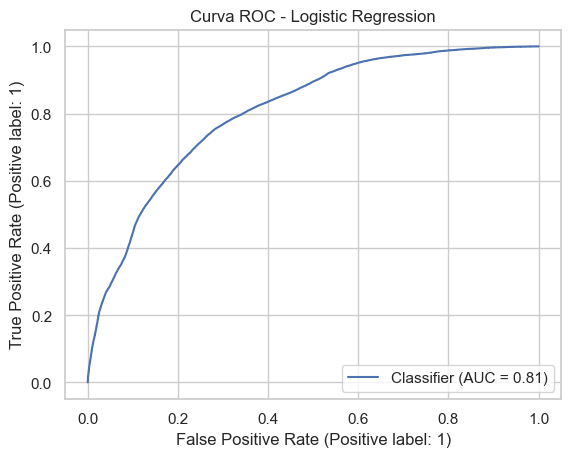


 Entrenando modelo: KNN
 Matriz de Confusión:
[[53830  3115]
 [  428 56517]]


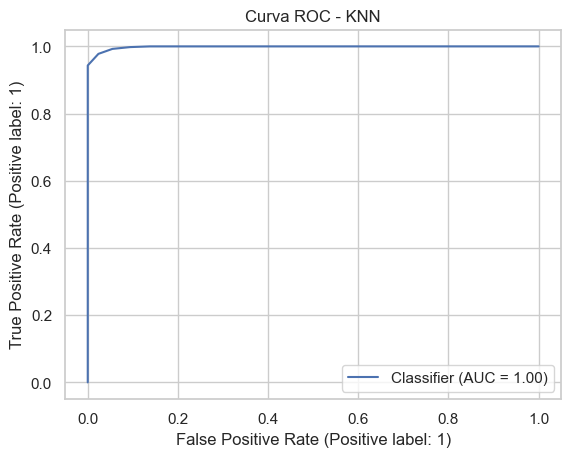


 Entrenando modelo: Naive Bayes
 Error entrenando Naive Bayes: The search_spaces parameter should contain at least onenon-empty search space, got {}

 Entrenando modelo: Decision Tree
 Matriz de Confusión:
[[51211  5734]
 [10657 46288]]


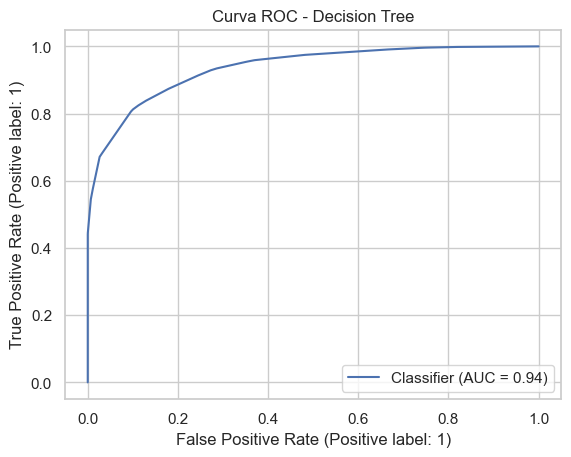


 Entrenando modelo: Random Forest
 Matriz de Confusión:
[[54143  2802]
 [ 5346 51599]]


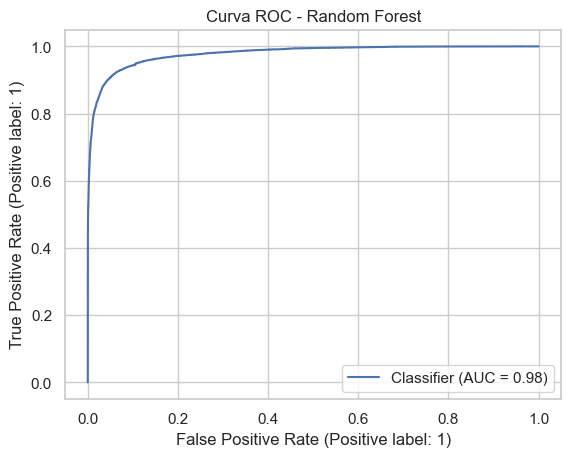


 Entrenando modelo: XGBoost


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:55:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:55:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:55:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:55:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, U

 Matriz de Confusión:
[[55780  1165]
 [ 3329 53616]]


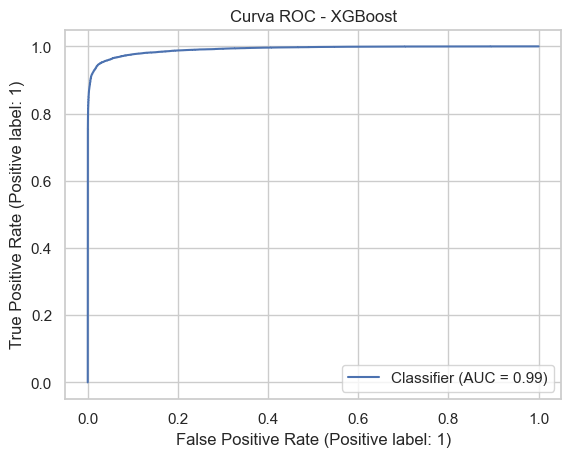

In [96]:
nombres_modelos = [
    "Logistic Regression",
    "KNN",
    "Naive Bayes",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

resultados_todos = []

for nombre in nombres_modelos:
    try:
        modelo, espacio = definir_modelo_y_espacio(nombre)
        resultado = entrenar_y_evaluar_modelo(nombre, modelo, espacio, X_train_res, y_train_res)
        resultados_todos.append(resultado)
    except Exception as e:
        print(f" Error entrenando {nombre}: {e}")

In [101]:
df_resultados = pd.DataFrame(resultados_todos)

df_resultados = df_resultados.sort_values(by='Recall', ascending=False).reset_index(drop=True)

print(df_resultados)
import plotly.express as px

fig = px.bar(
    df_resultados,
    x='Modelo',
    y='Recall',
    color='Recall',
    text='Recall',
    title='Comparación de Modelos - Clasificación de Fraude',
    height=500
)
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(showlegend=True)
fig.show()

                Modelo  Precision    Recall  F1-score       AUC  \
0                  KNN   0.947763  0.992484  0.969608  0.998340   
1              XGBoost   0.978734  0.941540  0.959777  0.991437   
2        Random Forest   0.948494  0.906120  0.926823  0.978568   
3        Decision Tree   0.889777  0.812855  0.849578  0.935362   
4  Logistic Regression   0.715795  0.774660  0.744065  0.807602   

                             Mejores Hiperparámetros  
0  {'kneighborsclassifier__n_neighbors': 5, 'knei...  
1  {'learning_rate': 0.15963496832524965, 'max_de...  
2  {'max_depth': 9, 'min_samples_split': 5, 'n_es...  
3           {'max_depth': 6, 'min_samples_split': 5}  
4      {'logisticregression__C': 0.6876831063110332}  


KNN es el mejor modelo en sensibilidad (Recall = 0.992)

- Este resultado indica que el modelo detecta el 99.2% de los fraudes, lo cual es ideal para tareas donde el costo de no detectar un fraude es muy alto.

- Aunque KNN puede ser computacionalmente costoso, su rendimiento en recall lo convierte en el modelo más confiable para minimizar falsos negativos.

XGBoost y Random Forest también muestran un alto Recall

- XGBoost con 0.942 y Random Forest con 0.906 ofrecen muy buen desempeño, aunque ligeramente inferior al de KNN.

- Ambos modelos presentan además un mejor balance entre precisión y recall que KNN, lo cual podría ser relevante en contextos con recursos limitados o necesidad de mayor robustez.

Regresión Logística queda muy por detrás

- Con un recall de 0.775, Logistic Regression deja pasar cerca del 23% de los fraudes reales, lo cual lo hace poco confiable como herramienta de detección efectiva.